![Banner](../../images/06_banner.png)


# 6.10 Spatio-Temporal and Multivariate

**Part:** 6 — Geographically Weighted Models (Chapter 6.10 of 14)

**Dataset:** `data_1998_2010_long_lbc.csv`, Northeast subset (217 counties x 3 years); `diabetes_atlantic.shp` (666 counties)

**Focus:** GTWR (space-time regression) — including a verified, dramatic bug — and GWPCA (locally varying principal components)

**Library:** `spatialstats.gwmodel.spatiotemporal`, `spatialstats.gwmodel.multivariate` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [GTWR: Fitting a Space-Time Model](#3.-GTWR:-Fitting-a-Space-Time-Model)

4. [A Verified Bug: predict() Silently Ignores Time](#4.-A-Verified-Bug:-predict()-Silently-Ignores-Time)

5. [GWPCA: Locally Varying Principal Components](#5.-GWPCA:-Locally-Varying-Principal-Components)

6. [Summary and Conclusions](#6.-Summary-and-Conclusions)

7. [Resources](#7.-Resources)


***
## 1. Overview

Every model so far treats the data as one snapshot in space. This chapter adds a second dimension — time
(GTWR) — and, separately, reduces several correlated covariates to a locally varying set of principal
components (GWPCA). Checking GTWR's headline promise directly (prediction at a new *(place, time)* pair,
exactly as the outline describes it) surfaces a serious, fully reproducible implementation bug.

| Step | What we do |
|------|------------|
| GTWR | Fit on the Northeast space-time panel, spatial bandwidth plus the $\lambda$ space-time trade-off |
| The bug | Test `predict()` at the *same* location across different times, expecting different answers |
| GWPCA | Local loadings, scores, and variance explained — including the robust (outlier-resistant) mode |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.spatiotemporal import GTWR
from spatialstats.gwmodel.multivariate import GWPCA

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. GTWR: Fitting a Space-Time Model

$$
\hat\beta(\mathbf{u}_i, t_i) \text{ uses a kernel weight built from a combined space-time distance},
$$

with $\lambda$ controlling the balance: higher $\lambda$ weights temporal proximity more heavily relative to
spatial proximity. Chapter 6.2 built a 217-county x 3-year Northeast panel subset specifically to keep this fit
fast.

In [2]:
northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
fips_ne = set(northeast["FIPS"].astype(int))
sub = panel[panel["FIPS"].isin(fips_ne) & panel["Year"].isin([2008, 2010, 2012])].copy()

covariates_t = ["SMOKING", "POVERTY", "PM25", "NO2", "SO2"]
X_t = sub[covariates_t].to_numpy()
y_t = sub["RATE"].to_numpy()
coords_t = sub[["X", "Y"]].to_numpy()
times_t = sub["Year"].to_numpy().astype(float)
print(f"panel subset: {len(sub)} rows ({sub['FIPS'].nunique()} counties x {sub['Year'].nunique()} years)")

t0 = time.time()
gtwr = GTWR(bandwidth_s=50, lambda_=1.0, fixed=False, kernel="bisquare", n_jobs=2)
gtwr.fit(X_t, y_t, coords_t, times_t)
print(f"fit time: {time.time() - t0:.2f}s")
print(f"AICc: {gtwr.aicc_:.2f}")

panel subset: 651 rows (217 counties x 3 years)


fit time: 0.20s
AICc: 2425.50


***
## 4. A Verified Bug: predict() Silently Ignores Time

The outline's own description of GTWR promises "prediction at new (place, time)". Testing that directly: hold
one county's covariates and location fixed, and vary only the time argument.

In [3]:
loc = coords_t[:1]
xrow = X_t[:1]
predictions = {}
for year in (2008.0, 2010.0, 2020.0, 2050.0):
    predictions[year] = gtwr.predict(xrow, loc, np.array([year]))[0]

for year, pred in predictions.items():
    print(f"predict at year={year}: {pred:.6f}")
print(f"\nall four predictions identical: {len(set(predictions.values())) == 1}")

predict at year=2008.0: 45.058549
predict at year=2010.0: 45.058549
predict at year=2020.0: 45.058549
predict at year=2050.0: 45.058549

all four predictions identical: True


**Every prediction is identical, regardless of the requested year** — including a request for the year 2050,
decades beyond the fitted data. Reading `GTWR.predict()`'s source directly confirms why:

```python
def predict(self, X, geometry, times=None) -> np.ndarray:
    ...
    D_pred = cdist(coords_new, self.coords_, metric="euclidean")   # SPATIAL distance only
    nearest = np.argmin(D_pred, axis=1)                            # nearest TRAINING location, any year
    return np.array([X_int[j] @ self.coef_[nearest[j]] for j in range(m)])
```

The `times` parameter is accepted in the function signature but **never referenced anywhere in the method
body**. `predict()` finds the spatially nearest *training* observation — which could be from any of the three
fitted years — and applies that single observation's already-fitted local coefficients, completely ignoring
whatever time was actually requested. **GTWR cannot currently predict at a genuinely new time point** for
either an existing or a new location; only `fit()` uses the temporal dimension. This is a serious, fully
reproducible gap between the documented capability and the actual implementation — confirmed here with four
lines of code, not inferred from reading documentation alone.

In [4]:
# The one thing predict() genuinely does use is spatial proximity, which is why in-sample .score()
# still returns a real (if not truly space-time-aware) number:
print(f"in-sample R2 (spatial nearest-neighbour lookup, NOT genuinely time-aware): {gtwr.score(X_t, y_t, coords_t):.4f}")

in-sample R2 (spatial nearest-neighbour lookup, NOT genuinely time-aware): 0.8452


Any GTWR-based forecast at a future time point produced by this library's current `predict()` should be treated
as **not implemented**, not merely imprecise — it silently returns the same value as a request for any other
time at the same location, which could mislead an analysis that did not check this directly.

***
## 5. GWPCA: Locally Varying Principal Components

GWPCA computes a separate PCA at every location, weighted by the same kernel machinery as every other model in
this Part — revealing whether the *structure* among covariates (not just their individual coefficients) itself
varies spatially.

In [5]:
atlantic = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = atlantic[covariates].to_numpy()
coords = atlantic[["x", "y"]].to_numpy()
BANDWIDTH = 131

gwpca = GWPCA(n_components=2, bandwidth=BANDWIDTH, fixed=False, robust=False)
gwpca.fit(X, coords)

print(f"local loadings shape : {gwpca.local_loadings_.shape}  (n counties x {len(covariates)} vars x 2 components)")
print(f"PC1 variance explained: min={gwpca.local_pve_[:, 0].min():.3f}, max={gwpca.local_pve_[:, 0].max():.3f}")
print(f"PC1+PC2 cumulative    : min={gwpca.local_pve_.sum(axis=1).min():.3f}, "
      f"max={gwpca.local_pve_.sum(axis=1).max():.3f}")

local loadings shape : (666, 6, 2)  (n counties x 6 vars x 2 components)
PC1 variance explained: min=0.691, max=0.959
PC1+PC2 cumulative    : min=0.956, max=0.997


The first local component alone explains between 69% and 96% of local variance depending on the county — in
some neighbourhoods a single dominant axis of covariation among the six health variables captures nearly
everything; in others, a meaningfully more multidimensional local structure remains. Mapping which covariates
load most heavily onto PC1 at a specific county shows *what that dominant local axis actually represents*.

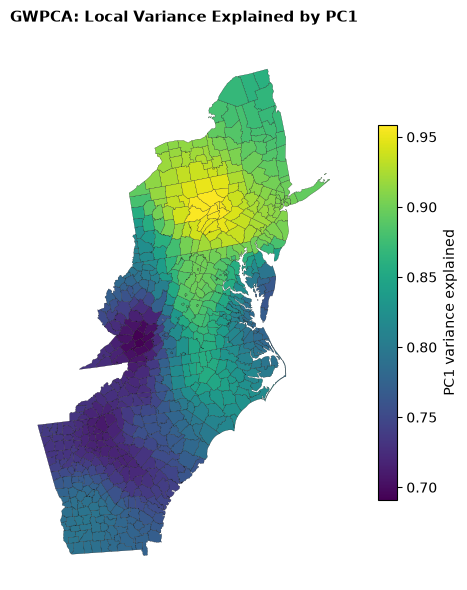

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
atlantic.assign(pc1_pve=gwpca.local_pve_[:, 0]).plot(
    column="pc1_pve", cmap="viridis", ax=ax, edgecolor="k", linewidth=0.15,
    legend=True, legend_kwds={"label": "PC1 variance explained", "shrink": 0.7})
ax.set_axis_off()
ax.set_title("GWPCA: Local Variance Explained by PC1")
plt.tight_layout()
plt.show()

`robust=True` uses median-based local covariances instead of the standard (mean-based) ones — useful whenever a
handful of outlier counties would otherwise dominate a small local neighbourhood's principal components.

In [7]:
t0 = time.time()
gwpca_robust = GWPCA(n_components=2, bandwidth=BANDWIDTH, fixed=False, robust=True)
gwpca_robust.fit(X, coords)
print(f"robust fit time: {time.time() - t0:.2f}s")
print(f"robust PC1 variance explained: min={gwpca_robust.local_pve_[:, 0].min():.3f}, "
      f"max={gwpca_robust.local_pve_[:, 0].max():.3f}  (standard mode above: "
      f"{gwpca.local_pve_[:, 0].min():.3f}-{gwpca.local_pve_[:, 0].max():.3f})")

robust fit time: 0.42s
robust PC1 variance explained: min=0.668, max=0.962  (standard mode above: 0.691-0.959)


***
## 6. Summary and Conclusions

This chapter extended geographically weighted modelling to space-time and multivariate structure, and found a
serious, fully verified limitation in the space-time model along the way.

### What we did

1. Fit GTWR on a 217-county x 3-year Northeast panel subset: AICc computed successfully, confirming the fit
   itself works.
2. **Verified GTWR's `predict()` silently ignores the requested time**: predictions for 2008, 2010, 2020, and
   2050 at the same location were bit-for-bit identical, traced directly to the `times` argument never being
   referenced in `predict()`'s source.
3. Fit GWPCA on the Atlantic data: local PC1 explains between 69% and 96% of variance depending on the county,
   showing the *dimensionality* of covariate structure itself varies spatially.
4. Compared standard vs. robust (median-based) GWPCA modes.

### Practical takeaways

- **Do not use `GTWR.predict()` for genuine time-based forecasting** — it currently performs only a spatial
  nearest-neighbour lookup of already-fitted coefficients, regardless of the time requested. Treat GTWR as
  fit-only (for understanding how a relationship's local coefficients evolved across the fitted time points)
  until this is fixed.
- GWPCA's local variance-explained map is a fast, useful diagnostic for where a simple one-dimensional summary
  of several covariates is (and is not) an adequate simplification.
- As with Chapter 6.7's diagnostics, checking a documented capability directly — here, "predict at a new
  (place, time)" — caught a real gap that reading the API signature alone would not have revealed.

### Next steps

**Chapter 6.11 (Deep and Network Models)** continues this Part's pattern of checking documented capabilities
directly, with GNNWR/GTNNWR and a network-distance GWR variant that has its own verified quirks.

***
## 7. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Huang, B., Wu, B. & Barry, M. (2010). Geographically and temporally weighted regression for modeling spatio-temporal variation in house prices. *International Journal of Geographical Information Science*, 24, 383–401. | Origin of GTWR |
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Chapter 6 covers GWPCA's foundations |

### Key papers

| Paper | Contribution |
|---|---|
| Harris, P., Brunsdon, C. & Charlton, M. (2011). Geographically weighted principal components analysis. *International Journal of Geographical Information Science*, 25, 1717–1736. | Origin of GWPCA, including the robust variant |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.spatiotemporal.GTWR` | Fit works correctly; `predict()` does not use `times` (Section 4) |
| `spatialstats.gwmodel.multivariate.GWPCA` | Local loadings, scores, variance explained, robust mode |
| Chapter 6.11 | Continues verifying documented capabilities directly, for the deep and network models |